# Crack Detection Pipeline

This notebook builds the computer vision part of an autonomous concrete infrastructure inspection robot prototype. It trains a crack/no-crack image classifier that can later provide crack probability to an inspection planner.

The current project is a laptop-runnable prototype. It does not claim to be a fully deployed robot system.

In [1]:
# pathlib creates clean file paths across operating systems.
from pathlib import Path

# sys lets the notebook import Python modules from the project src/ folder.
import sys

# deepcopy stores the best model weights during training.
from copy import deepcopy

# numpy handles numerical arrays and metric calculations.
import numpy as np

# pandas stores image paths, labels, and summary tables.
import pandas as pd

# matplotlib creates figures that are saved into outputs/.
import matplotlib.pyplot as plt

# PIL opens concrete image files for visualization and preprocessing.
from PIL import Image

# scikit-learn provides F1-score and a text classification report.
from sklearn.metrics import classification_report, f1_score

# PyTorch provides tensors, neural network layers, and model training tools.
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# torchvision provides standard image preprocessing transforms.
from torchvision import transforms

# display renders pandas tables cleanly in Jupyter.
from IPython.display import display

# Resolve the project root whether this notebook starts from the root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Add the project root to the import path so src/ modules are available.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import reusable project functions.
from src.data_loader import (
    create_train_val_test_split,
    detect_dataset_folders,
    load_image_paths,
    summarize_class_distribution,
)
from src.evaluate_model import calculate_metrics, plot_confusion_matrix, save_classification_report
from src.train_crack_detector import build_model, count_trainable_parameters, save_model
from src.visualization import plot_sample_images, plot_training_history

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Project root: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot
PyTorch version: 2.12.0+cpu
CUDA available: False


## Dataset Path and Configuration

Download the Concrete Crack Images for Classification dataset manually and place it under `data/raw/concrete_crack/`.

The code automatically supports either `Positive/Negative` or `crack/no_crack` class folders. Subset mode is enabled by default so the notebook can run quickly on a normal laptop.

In [2]:
# Main dataset folder. The class folders should be inside this directory.
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "concrete_crack"

# Output folders for reports, figures, and model files.
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Image and training configuration.
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 3
RANDOM_SEED = 42

# Keep training fast by default. Set USE_SUBSET to False to use all images.
USE_SUBSET = True
SAMPLES_PER_CLASS = 1000

print("Configuration")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"MODEL_DIR: {MODEL_DIR}")
print(f"IMAGE_SIZE: {IMAGE_SIZE}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"EPOCHS: {EPOCHS}")
print(f"USE_SUBSET: {USE_SUBSET}")
print(f"SAMPLES_PER_CLASS: {SAMPLES_PER_CLASS}")

Configuration
DATA_DIR: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\data\raw\concrete_crack
OUTPUT_DIR: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\outputs
MODEL_DIR: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\models
IMAGE_SIZE: (128, 128)
BATCH_SIZE: 32
EPOCHS: 3
USE_SUBSET: True
SAMPLES_PER_CLASS: 1000


In [3]:
# Confirm that the dataset exists before continuing.
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_DIR}\n"
        "Place the dataset under data/raw/concrete_crack/ and run this cell again."
    )

# Detect the supported class folder structure automatically.
CLASS_FOLDERS = detect_dataset_folders(DATA_DIR)

print("Detected class folders:")
for class_name, folder_path in CLASS_FOLDERS.items():
    print(f"  {class_name}: {folder_path}")

Detected class folders:
  crack: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\data\raw\concrete_crack\Positive
  no_crack: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\data\raw\concrete_crack\Negative


## Dataset Loading

This stage loads image file paths and labels into a pandas DataFrame. The image pixels are not loaded yet, which keeps the notebook memory-friendly.

Label convention: `0 = no_crack`, `1 = crack`.

In [4]:
# Load the full file list first so we can report the true dataset size.
full_df = load_image_paths(DATA_DIR, use_subset=False, random_seed=RANDOM_SEED)

print(f"Total number of images found: {len(full_df)}")
print(f"Number of crack images found: {(full_df['label'] == 1).sum()}")
print(f"Number of no-crack images found: {(full_df['label'] == 0).sum()}")

# Use a balanced subset for faster training unless USE_SUBSET is disabled.
if USE_SUBSET:
    df = load_image_paths(
        DATA_DIR,
        use_subset=True,
        samples_per_class=SAMPLES_PER_CLASS,
        random_seed=RANDOM_SEED,
    )
    print(f"\nSubset mode is ON. Images used in this run: {len(df)}")
else:
    df = full_df.copy()
    print(f"\nSubset mode is OFF. Images used in this run: {len(df)}")

# Create and display a class distribution table.
distribution_summary = summarize_class_distribution(df)
print("\nClass distribution table:")
display(distribution_summary)

Total number of images found: 40000
Number of crack images found: 20000
Number of no-crack images found: 20000



Subset mode is ON. Images used in this run: 2000

Class distribution table:


,class_name,label,count
0,no_crack,0,1000
1,crack,1,1000


In [5]:
# Save the class distribution table for documentation and reporting.
class_distribution_path = OUTPUT_DIR / "class_distribution.csv"
distribution_summary.to_csv(class_distribution_path, index=False)

print(f"Saved class distribution summary to: {class_distribution_path}")

Saved class distribution summary to: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\outputs\class_distribution.csv


## Sample Visualization

Before training, inspect a few examples from both classes. This checks that the dataset was loaded correctly and gives interviewers a concrete visual understanding of the task.

In [6]:
# Select a few image paths from each class. This cell prepares data only.
sample_rows = []
for class_name in ["crack", "no_crack"]:
    class_df = df[df["class_name"] == class_name]
    sample_rows.append(class_df.sample(n=min(4, len(class_df)), random_state=RANDOM_SEED))

sample_df = pd.concat(sample_rows, ignore_index=True)
print("Prepared sample image paths:")
display(sample_df[["class_name", "filepath"]])

Prepared sample image paths:


,class_name,filepath
0,crack,C:\Users\leoluo\Documents\Codex\2026-05-16\fil...
1,crack,C:\Users\leoluo\Documents\Codex\2026-05-16\fil...
2,crack,C:\Users\leoluo\Documents\Codex\2026-05-16\fil...
3,crack,C:\Users\leoluo\Documents\Codex\2026-05-16\fil...
4,no_crack,C:\Users\leoluo\Documents\Codex\2026-05-16\fil...
5,no_crack,C:\Users\leoluo\Documents\Codex\2026-05-16\fil...
6,no_crack,C:\Users\leoluo\Documents\Codex\2026-05-16\fil...
7,no_crack,C:\Users\leoluo\Documents\Codex\2026-05-16\fil...


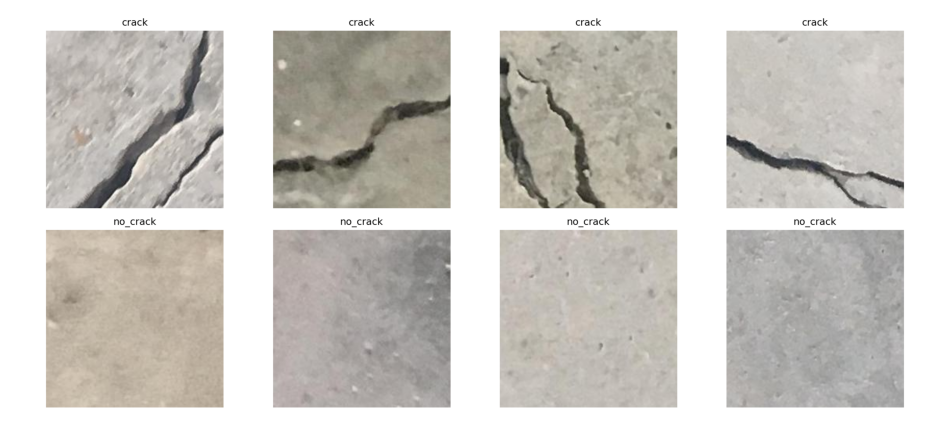

Saved sample visualization to: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\outputs\sample_images.png


In [7]:
# Plot and save sample crack and no-crack images.
sample_images_path = plot_sample_images(
    dataframe=df,
    output_path=OUTPUT_DIR / "sample_images.png",
    num_per_class=4,
    random_seed=RANDOM_SEED,
)

# Display the saved visualization as notebook output.
saved_sample_image = Image.open(sample_images_path)
plt.figure(figsize=(12, 7))
plt.imshow(saved_sample_image)
plt.axis("off")
plt.show()

print(f"Saved sample visualization to: {sample_images_path}")

## Train / Validation / Test Split

We use stratified sampling so each split keeps a similar class balance. The training set updates the model, the validation set monitors training, and the test set is held back for final evaluation.

In [8]:
# Create train, validation, and test splits.
train_df, val_df, test_df = create_train_val_test_split(
    df,
    val_size=0.15,
    test_size=0.15,
    random_seed=RANDOM_SEED,
)

# Print split sizes and class distributions.
for split_name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{split_name} split size: {len(split_df)}")
    display(split_df["class_name"].value_counts().rename_axis("class_name").reset_index(name="count"))


Train split size: 1400


,class_name,count
0,no_crack,700
1,crack,700



Validation split size: 300


,class_name,count
0,no_crack,150
1,crack,150



Test split size: 300


,class_name,count
0,no_crack,150
1,crack,150


## Image Preprocessing and PyTorch Dataset

The model trains on tensors, not file paths. A PyTorch `Dataset` opens one image at a time, applies preprocessing, and returns an image tensor with its label.

In [9]:
# Training transforms resize images, add a small random flip, convert to tensor, and normalize.
train_transform = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

# Evaluation transforms are deterministic so validation and test metrics are stable.
eval_transform = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

class CrackImageDataset(Dataset):
    """Dataset that reads concrete images from file paths stored in a DataFrame."""

    def __init__(self, dataframe, transform=None):
        # Reset the index so integer indexing works after splitting.
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        # Return the number of samples in this split.
        return len(self.dataframe)

    def __getitem__(self, index):
        # Read the image path and label from one DataFrame row.
        row = self.dataframe.iloc[index]

        # Open the image as RGB so every sample has three channels.
        image = Image.open(row["filepath"]).convert("RGB")
        label = int(row["label"])

        # Apply preprocessing if a transform pipeline was provided.
        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [10]:
# Create Dataset objects for each split.
train_dataset = CrackImageDataset(train_df, transform=train_transform)
val_dataset = CrackImageDataset(val_df, transform=eval_transform)
test_dataset = CrackImageDataset(test_df, transform=eval_transform)

# Create DataLoader objects to batch images during training and evaluation.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Inspect one batch to verify tensor dimensions.
batch_images, batch_labels = next(iter(train_loader))
print(f"Batch image tensor shape: {batch_images.shape}")
print(f"Batch label tensor shape: {batch_labels.shape}")
print("Shape meaning: [batch_size, color_channels, image_height, image_width]")

Batch image tensor shape: torch.Size([32, 3, 128, 128])
Batch label tensor shape: torch.Size([32])
Shape meaning: [batch_size, color_channels, image_height, image_width]


## Model Choice

This notebook uses a small custom CNN by default because it is easy to explain and quick to train. A future version could use `ResNet18` for stronger performance.

The model outputs two logits: one for `no_crack` and one for `crack`.

In [11]:
# Choose the model architecture.
MODEL_NAME = "simple_cnn"

# Use GPU if available; otherwise train on CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build the model and move it to the selected device.
model = build_model(model_name=MODEL_NAME, num_classes=2, pretrained=False).to(device)

# Count parameters so the model size is clear.
num_parameters = count_trainable_parameters(model)

print(model)
print(f"\nTrainable parameters: {num_parameters:,}")
print(f"Training device: {device}")

SimpleCrackCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(

## Training Loop

Each epoch passes through the training data, updates model weights, and then evaluates on the validation set. We track loss, accuracy, and F1-score.

In [12]:
# Cross-entropy loss is standard for multi-class classification logits.
criterion = nn.CrossEntropyLoss()

# Adam is a beginner-friendly optimizer that works well for small CNNs.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(model, dataloader, criterion, device, optimizer=None):
    """Run one training or evaluation epoch."""

    # optimizer is provided only during training.
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    # Gradients are only needed during training.
    with torch.set_grad_enabled(is_training):
        for images, labels in dataloader:
            # Move image and label tensors to CPU or GPU.
            images = images.to(device)
            labels = labels.to(device)

            # Clear gradients from the previous batch.
            if is_training:
                optimizer.zero_grad()

            # Forward pass through the model.
            logits = model(images)
            loss = criterion(logits, labels)

            # Backpropagation and optimizer step happen only in training mode.
            if is_training:
                loss.backward()
                optimizer.step()

            # Track loss and predictions for metrics.
            total_loss += loss.item() * labels.size(0)
            predictions = torch.argmax(logits, dim=1)
            all_labels.extend(labels.detach().cpu().numpy().tolist())
            all_predictions.extend(predictions.detach().cpu().numpy().tolist())

    average_loss = total_loss / len(dataloader.dataset)
    accuracy = np.mean(np.array(all_labels) == np.array(all_predictions))
    f1 = f1_score(all_labels, all_predictions, zero_division=0)

    return average_loss, accuracy, f1

In [13]:
# Train the model and keep the best validation-F1 checkpoint in memory.
history = []
best_val_f1 = -1.0
best_model_state = deepcopy(model.state_dict())

for epoch in range(1, EPOCHS + 1):
    # Train for one full pass over the training set.
    train_loss, train_accuracy, train_f1 = run_epoch(
        model, train_loader, criterion, device, optimizer=optimizer
    )

    # Evaluate once on the validation set without updating weights.
    val_loss, val_accuracy, val_f1 = run_epoch(model, val_loader, criterion, device)

    # Save metrics for plotting.
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "val_f1": val_f1,
        }
    )

    # Keep the best model weights based on validation F1-score.
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = deepcopy(model.state_dict())

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_accuracy:.4f} | "
        f"val_f1={val_f1:.4f}"
    )

# Restore the best validation model before final testing.
model.load_state_dict(best_model_state)

# Save the training history table.
history_df = pd.DataFrame(history)
history_csv_path = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_csv_path, index=False)
print(f"Saved training history table to: {history_csv_path}")

Epoch 1/3 | train_loss=0.3597 | val_loss=0.4166 | val_acc=0.8033 | val_f1=0.7649


Epoch 2/3 | train_loss=0.2140 | val_loss=0.2338 | val_acc=0.9533 | val_f1=0.9536


Epoch 3/3 | train_loss=0.1441 | val_loss=0.1472 | val_acc=0.9733 | val_f1=0.9733
Saved training history table to: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\outputs\training_history.csv


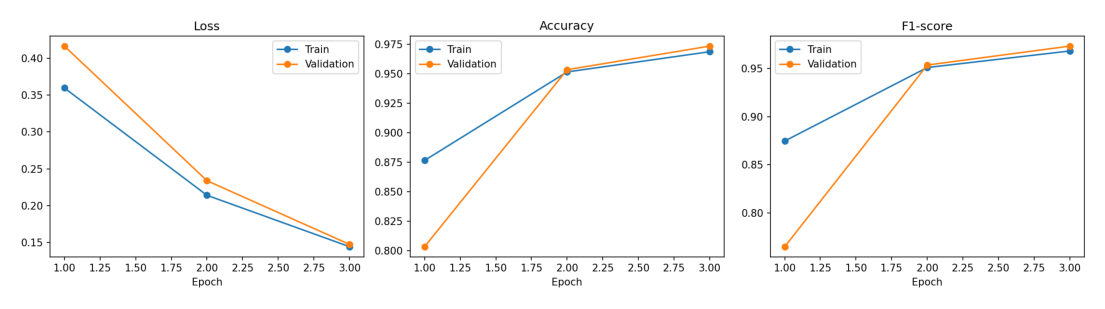

Saved training history plot to: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\outputs\training_history.png


In [14]:
# Plot and save the training history.
training_history_path = plot_training_history(
    history=history,
    output_path=OUTPUT_DIR / "training_history.png",
)

# Display the saved plot.
saved_history_image = Image.open(training_history_path)
plt.figure(figsize=(14, 4))
plt.imshow(saved_history_image)
plt.axis("off")
plt.show()

print(f"Saved training history plot to: {training_history_path}")

## Test Evaluation Metrics

The test set is used only after training. We calculate accuracy, precision, recall, F1-score, confusion matrix, and a classification report.

In [15]:
# Run inference over the test set.
model.eval()
y_true = []
y_pred = []
y_crack_probability = []

with torch.no_grad():
    for images, labels in test_loader:
        # Move test images to the selected device.
        images = images.to(device)

        # Forward pass and probability conversion.
        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)[:, 1]
        predictions = torch.argmax(logits, dim=1)

        # Store results on CPU for metric calculation.
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(predictions.cpu().numpy().tolist())
        y_crack_probability.extend(probabilities.cpu().numpy().tolist())

# Calculate metrics and a text report.
test_metrics = calculate_metrics(y_true, y_pred)
classification_report_text = classification_report(
    y_true,
    y_pred,
    target_names=["no_crack", "crack"],
    zero_division=0,
)

print("Test evaluation completed. Run the next cell to print and save the metrics.")

Test evaluation completed. Run the next cell to print and save the metrics.


In [16]:
# Print final test metrics clearly.
print("Final Test Metrics")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-score:  {test_metrics['f1']:.4f}")
print("\nClassification Report")
print(classification_report_text)

# Save the classification report to outputs/.
report_path = save_classification_report(
    y_true,
    y_pred,
    output_path=OUTPUT_DIR / "classification_report.txt",
    target_names=["no_crack", "crack"],
)
print(f"Saved classification report to: {report_path}")

Final Test Metrics
Accuracy:  0.9833
Precision: 0.9932
Recall:    0.9733
F1-score:  0.9832

Classification Report
              precision    recall  f1-score   support

    no_crack       0.97      0.99      0.98       150
       crack       0.99      0.97      0.98       150

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

Saved classification report to: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\outputs\classification_report.txt


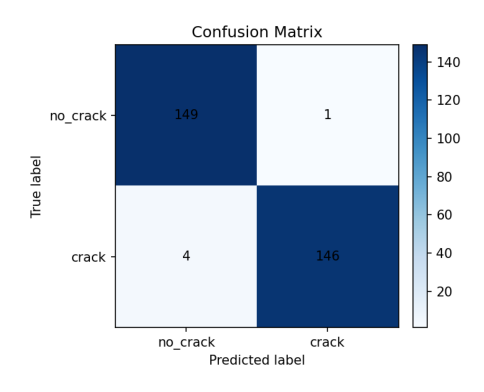

Saved confusion matrix to: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\outputs\confusion_matrix.png


In [17]:
# Plot and save the confusion matrix.
confusion_matrix_path = plot_confusion_matrix(
    matrix=test_metrics["confusion_matrix"],
    class_names=["no_crack", "crack"],
    output_path=OUTPUT_DIR / "confusion_matrix.png",
)

# Display the saved confusion matrix.
saved_confusion_matrix = Image.open(confusion_matrix_path)
plt.figure(figsize=(6, 5))
plt.imshow(saved_confusion_matrix)
plt.axis("off")
plt.show()

print(f"Saved confusion matrix to: {confusion_matrix_path}")

## Prediction Examples and Crack Probability

A robot planner benefits from crack probability, not just a hard class label. The next cells show example predictions with true label, predicted label, and crack probability.

In [18]:
# Select several test images and generate prediction probabilities.
prediction_sample_df = test_df.sample(n=min(8, len(test_df)), random_state=RANDOM_SEED).reset_index(drop=True)
prediction_results = []

model.eval()
with torch.no_grad():
    for _, row in prediction_sample_df.iterrows():
        # Open and preprocess one image.
        image = Image.open(row["filepath"]).convert("RGB")
        image_tensor = eval_transform(image).unsqueeze(0).to(device)

        # Convert model output into crack probability.
        logits = model(image_tensor)
        crack_probability = torch.softmax(logits, dim=1)[0, 1].item()
        predicted_label = "crack" if crack_probability >= 0.5 else "no_crack"

        # Store values for the display cell.
        prediction_results.append(
            {
                "filepath": row["filepath"],
                "true_label": row["class_name"],
                "predicted_label": predicted_label,
                "crack_probability": crack_probability,
            }
        )

prediction_results_df = pd.DataFrame(prediction_results)
print("Generated prediction probabilities:")
display(prediction_results_df[["true_label", "predicted_label", "crack_probability"]])

Generated prediction probabilities:


,true_label,predicted_label,crack_probability
0,crack,crack,0.668992
1,crack,crack,0.913777
2,crack,crack,0.999113
3,crack,crack,0.894792
4,no_crack,no_crack,0.079038
5,crack,crack,0.995778
6,no_crack,no_crack,0.099440
7,no_crack,no_crack,0.103918


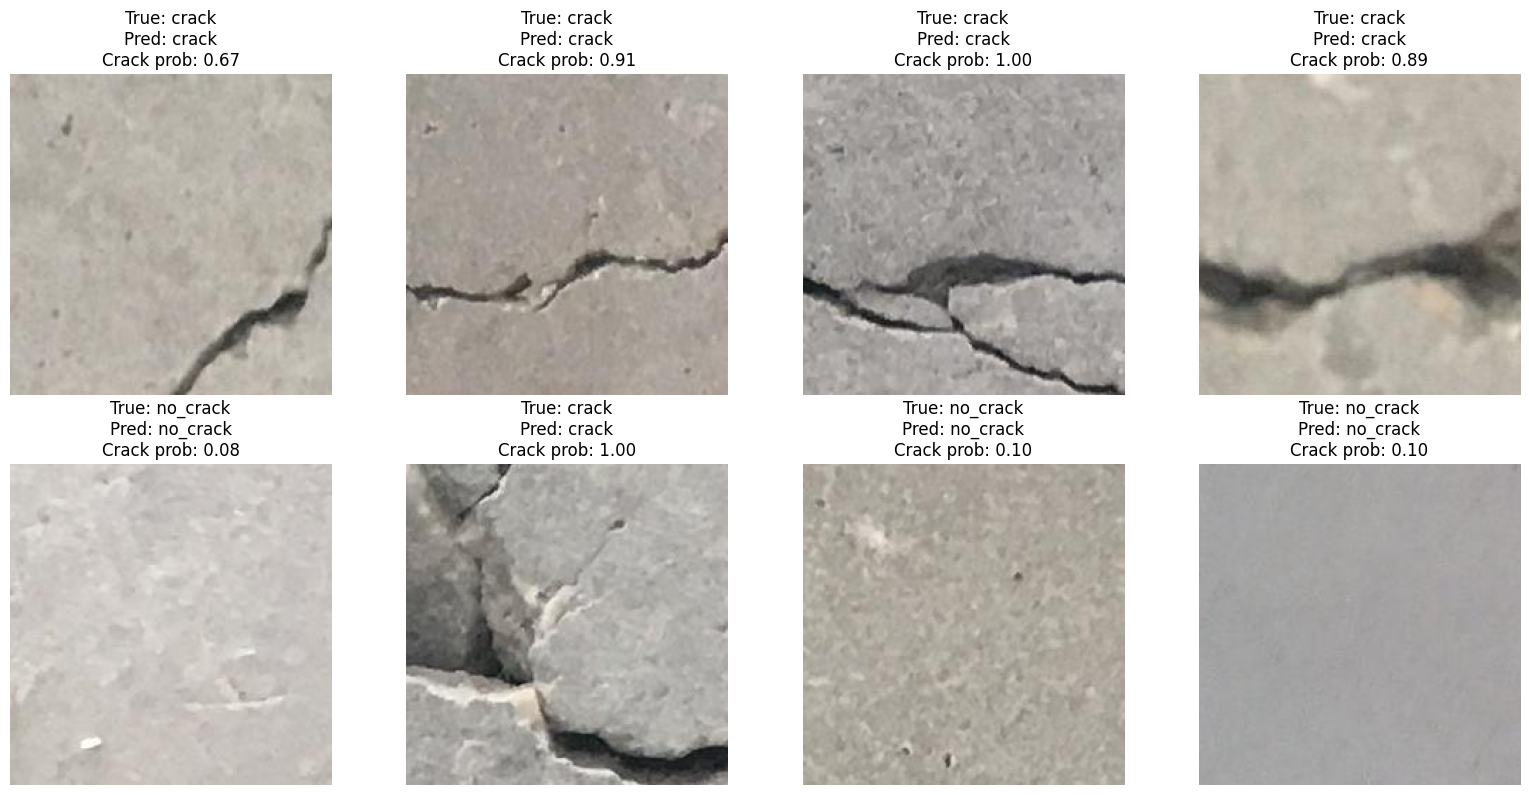

Saved prediction examples to: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\outputs\prediction_examples.png


In [19]:
# Display prediction examples and save the figure.
columns = min(4, len(prediction_results_df))
rows = int(np.ceil(len(prediction_results_df) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
axes = np.array(axes).reshape(-1)

for index, row in prediction_results_df.iterrows():
    # Show the original image with prediction text above it.
    image = Image.open(row["filepath"]).convert("RGB")
    axes[index].imshow(image)
    axes[index].axis("off")
    axes[index].set_title(
        f"True: {row['true_label']}\n"
        f"Pred: {row['predicted_label']}\n"
        f"Crack prob: {row['crack_probability']:.2f}"
    )

# Hide unused panels if the grid is not full.
for index in range(len(prediction_results_df), len(axes)):
    axes[index].axis("off")

fig.tight_layout()
prediction_examples_path = OUTPUT_DIR / "prediction_examples.png"
fig.savefig(prediction_examples_path, dpi=150)
plt.show()

print(f"Saved prediction examples to: {prediction_examples_path}")

## Model Saving

The model is saved as a PyTorch checkpoint with metadata needed by the Streamlit app, including model type, image size, and class names.

In [20]:
# Save the trained crack detector.
model_path = save_model(
    model=model,
    model_path=MODEL_DIR / "crack_detector.pt",
    image_size=IMAGE_SIZE,
    model_name=MODEL_NAME,
    class_names=["no_crack", "crack"],
    extra_metadata={"best_val_f1": best_val_f1},
)

print(f"Saved trained model to: {model_path}")

Saved trained model to: C:\Users\leoluo\Documents\Codex\2026-05-16\files-mentioned-by-the-user-5y9wdsg2zt\Autonomous-Concrete-Infrastructure-Inspection-Robot\models\crack_detector.pt


## Connection to Robot Inspection

The vision model connects to robot inspection like this:

```text
camera image -> crack detection model -> crack probability -> inspection planner
```

In a future ROS2 deployment, `crack_detection_node` could publish crack probability for `rl_planner_node`.

In [21]:
# Print a final summary of generated files.
print("Generated output files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    if path.is_file() and path.name != ".gitkeep":
        print(f"  outputs/{path.name}")

print("\nGenerated model files:")
for path in sorted(MODEL_DIR.glob("*")):
    if path.is_file() and path.name != ".gitkeep":
        print(f"  models/{path.name}")

Generated output files:
  outputs/class_distribution.csv
  outputs/classification_report.txt
  outputs/confusion_matrix.png
  outputs/crack_risk_map.png
  outputs/inspection_route.png
  outputs/prediction_examples.png
  outputs/README.md
  outputs/rl_training_rewards.png
  outputs/sample_images.png
  outputs/training_history.csv
  outputs/training_history.png

Generated model files:
  models/crack_detector.pt
